In [27]:
# ═══════════════════════════════════════════════════════════
# CELLULE 1 — IMPORTS
# Projet : Détection de Fraude Bancaire & Mobile Money
# Dataset : PaySim
# ═══════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Style des graphiques
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family']    = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Palette couleurs
BLEU   = '#2E75B6'
ROUGE  = '#C0392B'
VERT   = '#27AE60'
ORANGE = '#E67E22'
GRIS   = '#ECF0F1'

print("✅ Imports OK")

✅ Imports OK


In [28]:
# ═══════════════════════════════════════════════════════════
# CELLULE 2 — CHARGEMENT DU DATASET
# ═══════════════════════════════════════════════════════════

# Chemin vers le fichier
CHEMIN = '../data/transactions.csv'

# Chargement
print("⏳ Chargement en cours (fichier de 6,3M lignes, patiente 30s)...")
df = pd.read_csv(CHEMIN)
print(f"✅ Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

⏳ Chargement en cours (fichier de 6,3M lignes, patiente 30s)...
✅ Dataset chargé : 6,362,620 lignes × 11 colonnes


In [29]:
# ═══════════════════════════════════════════════════════════
# CELLULE 3 — PREMIÈRE VUE DU DATASET
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("APERÇU DES PREMIÈRES LIGNES")
print("=" * 60)
display(df.head(5))

print("\n" + "=" * 60)
print("TYPES ET VALEURS MANQUANTES")
print("=" * 60)
info = pd.DataFrame({
    'Type'            : df.dtypes,
    'Valeurs manquantes': df.isnull().sum(),
    'Taux manquant (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Exemples'        : [str(df[c].unique()[:3]) for c in df.columns]
})
display(info)

print("\n" + "=" * 60)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 60)
display(df.describe().round(2))

APERÇU DES PREMIÈRES LIGNES


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0



TYPES ET VALEURS MANQUANTES


,Type,Valeurs manquantes,Taux manquant (%),Exemples
step,int64,0,0.0,[1 2 3]
type,str,0,0.0,"<StringArray>\n['PAYMENT', 'TRANSFER', 'CASH_O..."
amount,float64,0,0.0,[9839.64 1864.28 181. ]
nameOrig,str,0,0.0,"<StringArray>\n['C1231006815', 'C1666544295', ..."
oldbalanceOrg,float64,0,0.0,[170136. 21249. 181.]
newbalanceOrig,float64,0,0.0,[160296.36 19384.72 0. ]
nameDest,str,0,0.0,"<StringArray>\n['M1979787155', 'M2044282225', ..."
oldbalanceDest,float64,0,0.0,[ 0. 21182. 41898.]
newbalanceDest,float64,0,0.0,[ 0. 40348.79 157982.12]
isFraud,int64,0,0.0,[0 1]



STATISTIQUES DESCRIPTIVES


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.00,6362620.00,6362620.00,6362620.00,6.362620e+06,6.362620e+06,6362620.00,6362620.0
mean,243.40,179861.90,833883.10,855113.67,1.100702e+06,1.224996e+06,0.00,0.0
std,142.33,603858.23,2888242.67,2924048.50,3.399180e+06,3.674129e+06,0.04,0.0
min,1.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
25%,156.00,13389.57,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
50%,239.00,74871.94,14208.00,0.00,1.327057e+05,2.146614e+05,0.00,0.0
75%,335.00,208721.48,107315.18,144258.41,9.430367e+05,1.111909e+06,0.00,0.0
max,743.00,92445516.64,59585040.37,49585040.37,3.560159e+08,3.561793e+08,1.00,1.0


DISTRIBUTION DE LA VARIABLE CIBLE : isFraud
  Transactions normales (0) :  6,354,407  (99.871%)
  Transactions frauduleuses (1):   8,213  (0.129%)
  Ratio déséquilibre        : 1 fraude / 773 normales


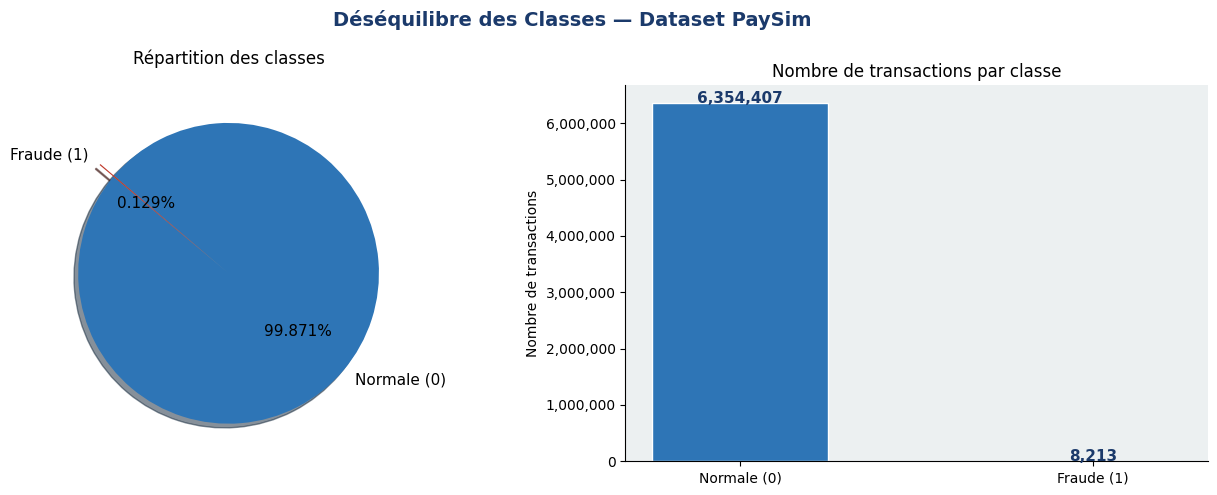

✅ Graphique sauvegardé dans models/


In [30]:
# ═══════════════════════════════════════════════════════════
# CELLULE 4 — ANALYSE DU DÉSÉQUILIBRE DES CLASSES
# ═══════════════════════════════════════════════════════════

counts = df['isFraud'].value_counts()
pcts   = df['isFraud'].value_counts(normalize=True) * 100

print("=" * 50)
print("DISTRIBUTION DE LA VARIABLE CIBLE : isFraud")
print("=" * 50)
print(f"  Transactions normales (0) : {counts[0]:>10,}  ({pcts[0]:.3f}%)")
print(f"  Transactions frauduleuses (1): {counts[1]:>7,}  ({pcts[1]:.3f}%)")
print(f"  Ratio déséquilibre        : 1 fraude / {int(counts[0]/counts[1])} normales")

# ── Graphique
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Déséquilibre des Classes — Dataset PaySim",
             fontsize=14, fontweight='bold', color='#1B3A6B')

# Camembert
axes[0].pie(
    [counts[0], counts[1]],
    labels=['Normale (0)', 'Fraude (1)'],
    colors=[BLEU, ROUGE],
    autopct='%1.3f%%',
    explode=(0, 0.12),
    shadow=True,
    startangle=140,
    textprops={'fontsize': 11}
)
axes[0].set_title("Répartition des classes", fontsize=12, pad=15)

# Barres
bars = axes[1].bar(
    ['Normale (0)', 'Fraude (1)'],
    [counts[0], counts[1]],
    color=[BLEU, ROUGE],
    edgecolor='white',
    width=0.5
)
axes[1].set_title("Nombre de transactions par classe", fontsize=12)
axes[1].set_ylabel("Nombre de transactions")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
axes[1].set_facecolor(GRIS)
for bar, val in zip(bars, [counts[0], counts[1]]):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5000,
        f'{val:,}',
        ha='center', fontsize=11,
        fontweight='bold', color='#1B3A6B'
    )

plt.tight_layout()
plt.savefig('../models/eda_desequilibre.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé dans models/")

Types de transactions présents :
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

FRAUDES PAR TYPE DE TRANSACTION


,Nb_Fraudes,Taux_Fraude
type,,
CASH_OUT,4116,0.184
TRANSFER,4097,0.769
CASH_IN,0,0.000
DEBIT,0,0.000
PAYMENT,0,0.000


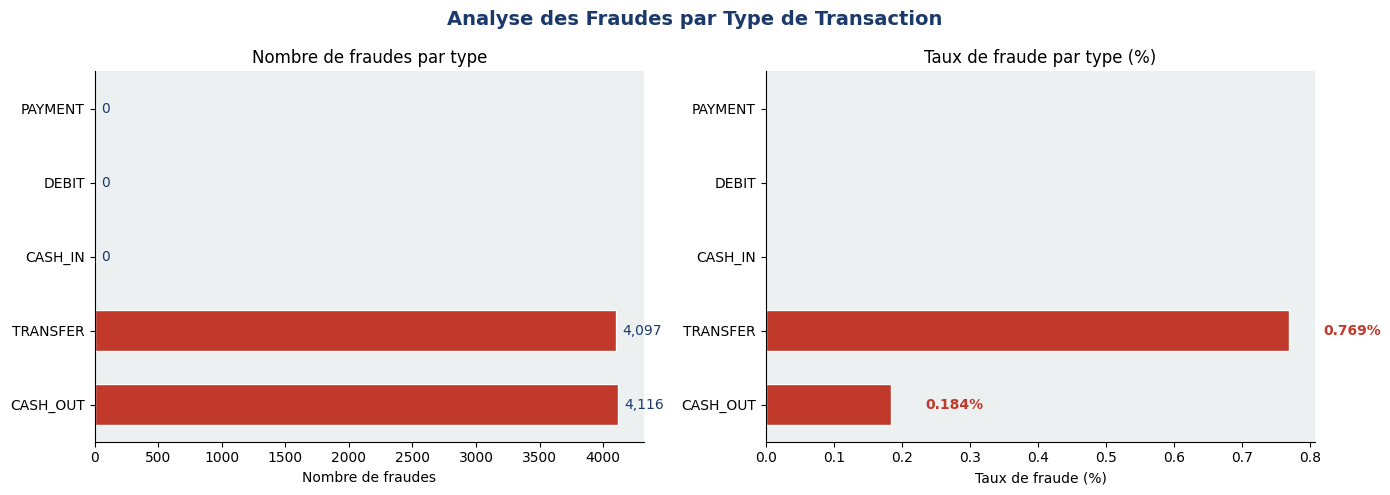

In [31]:
# ═══════════════════════════════════════════════════════════
# CELLULE 5 — TYPES DE TRANSACTIONS
# ═══════════════════════════════════════════════════════════

print("Types de transactions présents :")
print(df['type'].value_counts())

# Fraudes par type de transaction
fraudes_par_type = df.groupby('type')['isFraud'].agg(['sum', 'mean'])
fraudes_par_type.columns = ['Nb_Fraudes', 'Taux_Fraude']
fraudes_par_type['Taux_Fraude'] = (fraudes_par_type['Taux_Fraude'] * 100).round(3)
fraudes_par_type = fraudes_par_type.sort_values('Nb_Fraudes', ascending=False)

print("\n" + "=" * 50)
print("FRAUDES PAR TYPE DE TRANSACTION")
print("=" * 50)
display(fraudes_par_type)

# ── Graphique
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Analyse des Fraudes par Type de Transaction",
             fontsize=14, fontweight='bold', color='#1B3A6B')

# Nombre de fraudes
colors_type = [ROUGE if v > 0 else BLEU
               for v in fraudes_par_type['Nb_Fraudes']]
axes[0].barh(
    fraudes_par_type.index,
    fraudes_par_type['Nb_Fraudes'],
    color=colors_type, edgecolor='white', height=0.55
)
axes[0].set_title("Nombre de fraudes par type", fontsize=12)
axes[0].set_xlabel("Nombre de fraudes")
axes[0].set_facecolor(GRIS)
for i, val in enumerate(fraudes_par_type['Nb_Fraudes']):
    axes[0].text(val + 50, i, f'{val:,}',
                 va='center', fontsize=10, color='#1B3A6B')

# Taux de fraude
axes[1].barh(
    fraudes_par_type.index,
    fraudes_par_type['Taux_Fraude'],
    color=colors_type, edgecolor='white', height=0.55
)
axes[1].set_title("Taux de fraude par type (%)", fontsize=12)
axes[1].set_xlabel("Taux de fraude (%)")
axes[1].set_facecolor(GRIS)
for i, val in enumerate(fraudes_par_type['Taux_Fraude']):
    if val > 0:
        axes[1].text(val + 0.05, i, f'{val}%',
                     va='center', fontsize=10, color=ROUGE,
                     fontweight='bold')

plt.tight_layout()
plt.savefig('../models/eda_types.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# ═══════════════════════════════════════════════════════════
# CELLULE 7 — BILAN DE L'EXPLORATION
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("  BILAN DE L'EXPLORATION (EDA)")
print("=" * 60)
print(f"""
📊 Dataset PaySim
   ├─ Lignes totales    : {len(df):,}
   ├─ Colonnes          : {df.shape[1]}
   ├─ Valeurs manquantes: {df.isnull().sum().sum()}  ✅ aucune
   └─ Période couverte  : {df['step'].min()} à {df['step'].max()} steps

🎯 Variable cible : isFraud
   ├─ Transactions normales  : {counts[0]:,} ({pcts[0]:.2f}%)
   ├─ Transactions frauduleuses: {counts[1]:,} ({pcts[1]:.2f}%)
   └─ Déséquilibre extrême → SMOTE obligatoire

🔍 Observations clés
   ├─ Seuls CASH_OUT et TRANSFER contiennent des fraudes
   ├─ Les montants frauduleux sont en moyenne plus élevés
   ├─ Aucune valeur manquante → pas d'imputation nécessaire
   └─ La colonne 'step' représente l'heure (1 step = 1 heure)

⚙️  Colonnes disponibles : {list(df.columns)}
""")

print("✅ EDA terminée — on passe au Prétraitement (Étape 3)")

  BILAN DE L'EXPLORATION (EDA)

📊 Dataset PaySim
   ├─ Lignes totales    : 6,362,620
   ├─ Colonnes          : 11
   ├─ Valeurs manquantes: 0  ✅ aucune
   └─ Période couverte  : 1 à 743 steps

🎯 Variable cible : isFraud
   ├─ Transactions normales  : 6,354,407 (99.87%)
   ├─ Transactions frauduleuses: 8,213 (0.13%)
   └─ Déséquilibre extrême → SMOTE obligatoire

🔍 Observations clés
   ├─ Seuls CASH_OUT et TRANSFER contiennent des fraudes
   ├─ Les montants frauduleux sont en moyenne plus élevés
   ├─ Aucune valeur manquante → pas d'imputation nécessaire
   └─ La colonne 'step' représente l'heure (1 step = 1 heure)

⚙️  Colonnes disponibles : ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

✅ EDA terminée — on passe au Prétraitement (Étape 3)


In [33]:
# ═══════════════════════════════════════════════════════════
# CELLULE 8 — FILTRAGE
# Seuls CASH_OUT et TRANSFER contiennent des fraudes
# On garde uniquement ces deux types pour l'entraînement
# ═══════════════════════════════════════════════════════════

print(f"Taille avant filtrage : {df.shape[0]:,} lignes")

df_model = df[df['type'].isin(['CASH_OUT', 'TRANSFER'])].copy()

print(f"Taille après filtrage : {df_model.shape[0]:,} lignes")
print(f"Fraudes conservées    : {df_model['isFraud'].sum():,}")
print(f"Taux de fraude        : {df_model['isFraud'].mean()*100:.3f}%")

# Vérification
print(f"\nTypes restants : {df_model['type'].unique()}")
print("✅ Filtrage OK")# ═══════════════════════════════════════════════════════════
# CELLULE 9 — FEATURE ENGINEERING
# Création des 6 variables décrites dans le cahier des charges
# ═══════════════════════════════════════════════════════════

print("⏳ Création des nouvelles variables...")

# ── Variable 1 : écart de solde de l'émetteur
# Différence entre ce qu'on attend et ce qu'on observe
df_model['ecart_solde_emetteur'] = (
    df_model['oldbalanceOrg'] - df_model['amount'] - df_model['newbalanceOrig']
)

# ── Variable 2 : écart de solde du bénéficiaire
df_model['ecart_solde_beneficiaire'] = (
    df_model['oldbalanceDest'] + df_model['amount'] - df_model['newbalanceDest']
)

# ── Variable 3 : heure de la transaction
# Dans PaySim, 'step' = heure (1 step = 1 heure, sur 30 jours)
df_model['heure_transaction'] = df_model['step'] % 24

# ── Variable 4 : transaction nocturne (entre 22h et 6h)
df_model['est_transaction_nocturne'] = (
    (df_model['heure_transaction'] >= 22) |
    (df_model['heure_transaction'] <= 6)
).astype(int)

# ── Variable 5 : ratio montant / solde avant émetteur
# Évite la division par zéro avec + 1
df_model['ratio_montant'] = (
    df_model['amount'] / (df_model['oldbalanceOrg'] + 1)
)

# ── Variable 6 : le bénéficiaire est-il un client (C) ou un marchand (M) ?
df_model['beneficiaire_est_client'] = (
    df_model['nameDest'].str.startswith('C')
).astype(int)

print("✅ Variables créées :")
nouvelles_vars = [
    'ecart_solde_emetteur',
    'ecart_solde_beneficiaire',
    'heure_transaction',
    'est_transaction_nocturne',
    'ratio_montant',
    'beneficiaire_est_client'
]
for v in nouvelles_vars:
    print(f"   ├─ {v} : {df_model[v].dtype} | exemple = {df_model[v].iloc[0]:.4f}")

Taille avant filtrage : 6,362,620 lignes
Taille après filtrage : 2,770,409 lignes
Fraudes conservées    : 8,213
Taux de fraude        : 0.296%

Types restants : <StringArray>
['TRANSFER', 'CASH_OUT']
Length: 2, dtype: str
✅ Filtrage OK
⏳ Création des nouvelles variables...
✅ Variables créées :
   ├─ ecart_solde_emetteur : float64 | exemple = 0.0000
   ├─ ecart_solde_beneficiaire : float64 | exemple = 181.0000
   ├─ heure_transaction : int64 | exemple = 1.0000
   ├─ est_transaction_nocturne : int64 | exemple = 1.0000
   ├─ ratio_montant : float64 | exemple = 0.9945
   ├─ beneficiaire_est_client : int64 | exemple = 1.0000


In [34]:
# ═══════════════════════════════════════════════════════════
# CELLULE 9 — FEATURE ENGINEERING
# Création des 6 variables décrites dans le cahier des charges
# ═══════════════════════════════════════════════════════════

print("⏳ Création des nouvelles variables...")

# ── Variable 1 : écart de solde de l'émetteur
# Différence entre ce qu'on attend et ce qu'on observe
df_model['ecart_solde_emetteur'] = (
    df_model['oldbalanceOrg'] - df_model['amount'] - df_model['newbalanceOrig']
)

# ── Variable 2 : écart de solde du bénéficiaire
df_model['ecart_solde_beneficiaire'] = (
    df_model['oldbalanceDest'] + df_model['amount'] - df_model['newbalanceDest']
)

# ── Variable 3 : heure de la transaction
# Dans PaySim, 'step' = heure (1 step = 1 heure, sur 30 jours)
df_model['heure_transaction'] = df_model['step'] % 24

# ── Variable 4 : transaction nocturne (entre 22h et 6h)
df_model['est_transaction_nocturne'] = (
    (df_model['heure_transaction'] >= 22) |
    (df_model['heure_transaction'] <= 6)
).astype(int)

# ── Variable 5 : ratio montant / solde avant émetteur
# Évite la division par zéro avec + 1
df_model['ratio_montant'] = (
    df_model['amount'] / (df_model['oldbalanceOrg'] + 1)
)

# ── Variable 6 : le bénéficiaire est-il un client (C) ou un marchand (M) ?
df_model['beneficiaire_est_client'] = (
    df_model['nameDest'].str.startswith('C')
).astype(int)

print("✅ Variables créées :")
nouvelles_vars = [
    'ecart_solde_emetteur',
    'ecart_solde_beneficiaire',
    'heure_transaction',
    'est_transaction_nocturne',
    'ratio_montant',
    'beneficiaire_est_client'
]
for v in nouvelles_vars:
    print(f"   ├─ {v} : {df_model[v].dtype} | exemple = {df_model[v].iloc[0]:.4f}")

⏳ Création des nouvelles variables...
✅ Variables créées :
   ├─ ecart_solde_emetteur : float64 | exemple = 0.0000
   ├─ ecart_solde_beneficiaire : float64 | exemple = 181.0000
   ├─ heure_transaction : int64 | exemple = 1.0000
   ├─ est_transaction_nocturne : int64 | exemple = 1.0000
   ├─ ratio_montant : float64 | exemple = 0.9945
   ├─ beneficiaire_est_client : int64 | exemple = 1.0000


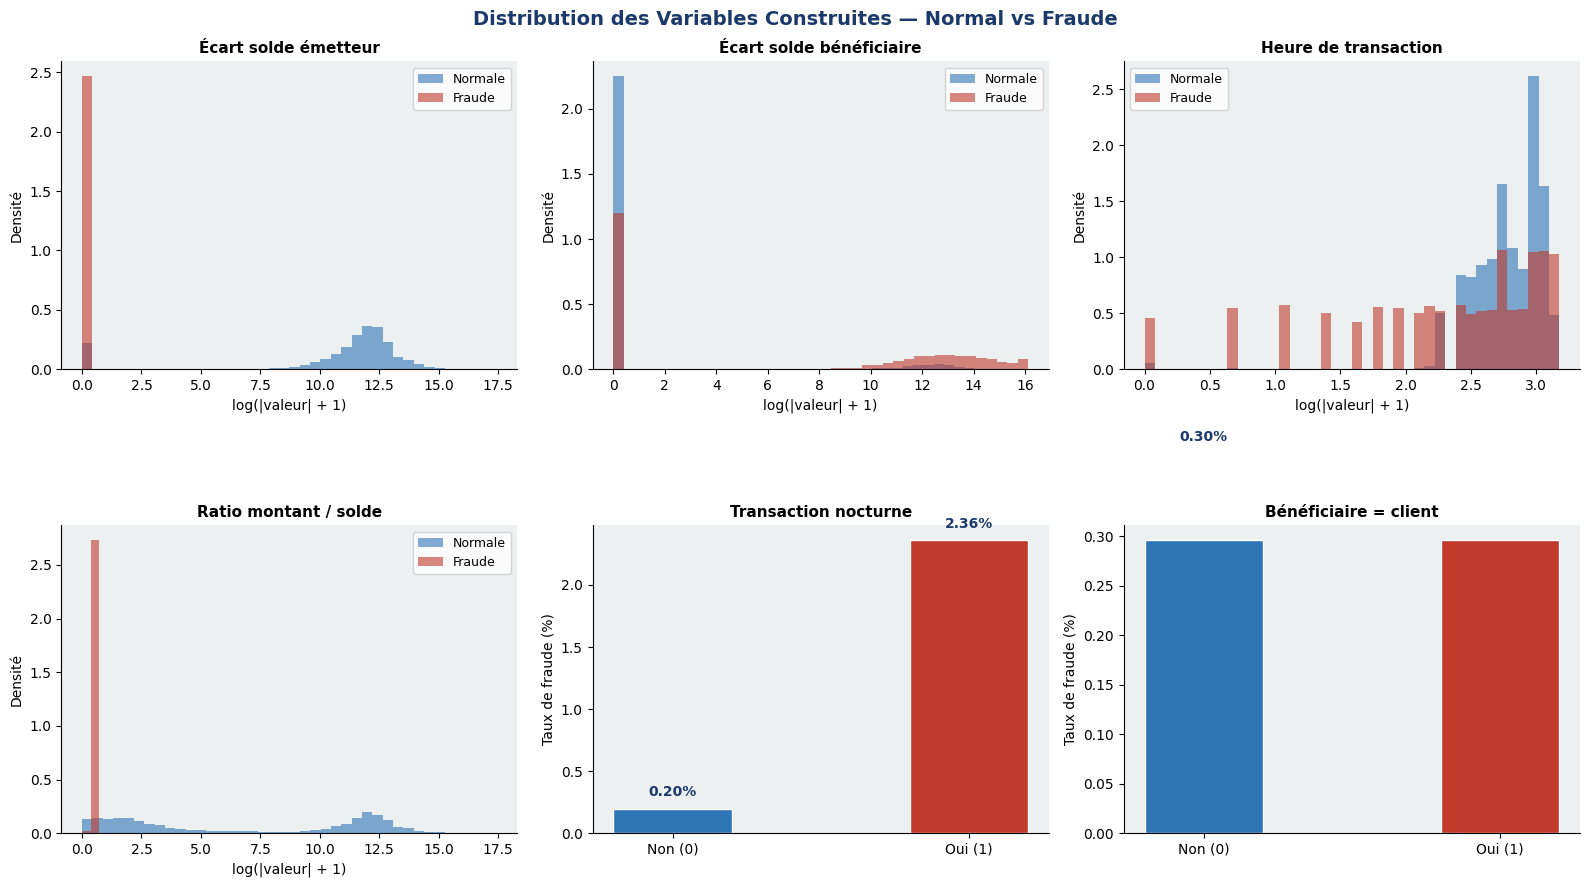

✅ Graphique sauvegardé


In [35]:
# ═══════════════════════════════════════════════════════════
# CELLULE 10 — VISUALISATION DES FEATURES ENGINEERÉES
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distribution des Variables Construites — Normal vs Fraude",
             fontsize=14, fontweight='bold', color='#1B3A6B')

vars_continues = [
    ('ecart_solde_emetteur',      "Écart solde émetteur"),
    ('ecart_solde_beneficiaire',  "Écart solde bénéficiaire"),
    ('heure_transaction',         "Heure de transaction"),
    ('ratio_montant',             "Ratio montant / solde"),
]
vars_binaires = [
    ('est_transaction_nocturne',  "Transaction nocturne"),
    ('beneficiaire_est_client',   "Bénéficiaire = client"),
]

normaux = df_model[df_model['isFraud'] == 0]
fraudes = df_model[df_model['isFraud'] == 1]

# Variables continues — histogrammes
for ax, (col, titre) in zip(axes.flat[:4], vars_continues):
    ax.hist(
        np.log1p(np.abs(normaux[col].sample(
            min(5000, len(normaux)), random_state=42))),
        bins=40, color=BLEU, alpha=0.6, label='Normale', density=True
    )
    ax.hist(
        np.log1p(np.abs(fraudes[col])),
        bins=40, color=ROUGE, alpha=0.6, label='Fraude', density=True
    )
    ax.set_title(titre, fontsize=11, fontweight='bold')
    ax.set_xlabel("log(|valeur| + 1)")
    ax.set_ylabel("Densité")
    ax.legend(fontsize=9)
    ax.set_facecolor(GRIS)

# Variables binaires — barres
for ax, (col, titre) in zip(axes.flat[4:], vars_binaires):
    taux = df_model.groupby(col)['isFraud'].mean() * 100
    bars = ax.bar(
        ['Non (0)', 'Oui (1)'],
        taux.values,
        color=[BLEU, ROUGE],
        edgecolor='white',
        width=0.4
    )
    ax.set_title(titre, fontsize=11, fontweight='bold')
    ax.set_ylabel("Taux de fraude (%)")
    ax.set_facecolor(GRIS)
    for bar, val in zip(bars, taux.values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{val:.2f}%',
            ha='center', fontsize=10, fontweight='bold', color='#1B3A6B'
        )

plt.tight_layout()
plt.savefig('../models/feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé")

In [36]:
# ═══════════════════════════════════════════════════════════
# CELLULE 11 — SÉLECTION DES COLONNES FINALES
# ═══════════════════════════════════════════════════════════

# Colonnes à garder pour le modèle
FEATURES_NUMERIQUES = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'ecart_solde_emetteur',
    'ecart_solde_beneficiaire',
    'heure_transaction',
    'ratio_montant',
]

FEATURES_BINAIRES = [
    'est_transaction_nocturne',
    'beneficiaire_est_client',
]

FEATURE_CATEGORIE = ['type']   # sera encodée en One-Hot

CIBLE = 'isFraud'

TOUTES_FEATURES = FEATURES_NUMERIQUES + FEATURES_BINAIRES + FEATURE_CATEGORIE

# Création du dataframe final
X = df_model[TOUTES_FEATURES].copy()
y = df_model[CIBLE].copy()

print("=" * 50)
print("DATASET FINAL POUR LA MODÉLISATION")
print("=" * 50)
print(f"  X (features) : {X.shape[0]:,} lignes × {X.shape[1]} colonnes")
print(f"  y (cible)    : {y.shape[0]:,} valeurs")
print(f"  Fraudes      : {y.sum():,} ({y.mean()*100:.3f}%)")
print(f"\n  Features utilisées :")
for f in TOUTES_FEATURES:
    print(f"    ├─ {f}")
print(f"\n  Cible : {CIBLE}")
print("\n✅ Sélection des colonnes OK")

DATASET FINAL POUR LA MODÉLISATION
  X (features) : 2,770,409 lignes × 12 colonnes
  y (cible)    : 2,770,409 valeurs
  Fraudes      : 8,213 (0.296%)

  Features utilisées :
    ├─ amount
    ├─ oldbalanceOrg
    ├─ newbalanceOrig
    ├─ oldbalanceDest
    ├─ newbalanceDest
    ├─ ecart_solde_emetteur
    ├─ ecart_solde_beneficiaire
    ├─ heure_transaction
    ├─ ratio_montant
    ├─ est_transaction_nocturne
    ├─ beneficiaire_est_client
    ├─ type

  Cible : isFraud

✅ Sélection des colonnes OK


In [37]:
# ═══════════════════════════════════════════════════════════
# CELLULE 12 — SPLIT TRAIN / TEST
# Séparation AVANT toute transformation (règle absolue)
# ═══════════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # maintient le ratio de fraudes dans chaque split
)

print("=" * 50)
print("SPLIT TRAIN / TEST (80% / 20%)")
print("=" * 50)
print(f"  Train : {X_train.shape[0]:,} lignes")
print(f"    ├─ Fraudes : {y_train.sum():,} ({y_train.mean()*100:.3f}%)")
print(f"  Test  : {X_test.shape[0]:,} lignes")
print(f"    ├─ Fraudes : {y_test.sum():,} ({y_test.mean()*100:.3f}%)")
print("\n✅ Split stratifié OK — ratio de fraudes identique dans train et test")

SPLIT TRAIN / TEST (80% / 20%)
  Train : 2,216,327 lignes
    ├─ Fraudes : 6,570 (0.296%)
  Test  : 554,082 lignes
    ├─ Fraudes : 1,643 (0.297%)

✅ Split stratifié OK — ratio de fraudes identique dans train et test


In [38]:
# ═══════════════════════════════════════════════════════════
# CELLULE 13 — PIPELINE DE PRÉTRAITEMENT COMPLET
# One-Hot Encoding + StandardScaler + SMOTE
# ═══════════════════════════════════════════════════════════

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

# ── Transformations par type de colonne
preprocessor = ColumnTransformer(transformers=[
    # Standardisation des variables numériques
    ('num', StandardScaler(), FEATURES_NUMERIQUES),
    # One-Hot Encoding de la variable catégorielle 'type'
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     FEATURE_CATEGORIE),
    # Les variables binaires passent sans transformation
    ('bin', 'passthrough', FEATURES_BINAIRES),
])

# ── Application sur le train
print("⏳ Application du prétraitement sur X_train...")
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print(f"✅ X_train prétraité : {X_train_prep.shape}")
print(f"✅ X_test  prétraité : {X_test_prep.shape}")

# ── SMOTE uniquement sur le train
print("\n⏳ Application de SMOTE sur le train...")
smote = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train)

print(f"✅ Avant SMOTE : {X_train_prep.shape[0]:,} lignes")
print(f"✅ Après SMOTE : {X_train_res.shape[0]:,} lignes")
print(f"   Fraudes après SMOTE : {y_train_res.sum():,} "
      f"({y_train_res.mean()*100:.1f}%)")

# ── Sauvegarde du préprocesseur
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(preprocessor, '../models/preprocessor.pkl')
print("\n✅ Préprocesseur sauvegardé → models/preprocessor.pkl")

⏳ Application du prétraitement sur X_train...
✅ X_train prétraité : (2216327, 13)
✅ X_test  prétraité : (554082, 13)

⏳ Application de SMOTE sur le train...
✅ Avant SMOTE : 2,216,327 lignes
✅ Après SMOTE : 2,872,684 lignes
   Fraudes après SMOTE : 662,927 (23.1%)

✅ Préprocesseur sauvegardé → models/preprocessor.pkl


In [39]:
# ═══════════════════════════════════════════════════════════
# CELLULE 14 — IMPORTS MODÉLISATION
# ═══════════════════════════════════════════════════════════

from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from xgboost                 import XGBClassifier
from lightgbm                import LGBMClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    recall_score,
    precision_score
)

import json
import time

print("✅ Imports modélisation OK")

✅ Imports modélisation OK


In [40]:
# ═══════════════════════════════════════════════════════════
# CELLULE 15 — DÉFINITION DES 4 MODÈLES
# ═══════════════════════════════════════════════════════════

# Calcul du poids pour gérer le déséquilibre
ratio = int((y_train == 0).sum() / (y_train == 1).sum())
print(f"Ratio déséquilibre : 1 fraude pour {ratio} normales")

MODELES = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=ratio,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss',
        verbosity=0,
        n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        class_weight='balanced',
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        verbose=-1,
        n_jobs=-1
    ),
}

print(f"\n✅ {len(MODELES)} modèles définis :")
for nom in MODELES:
    print(f"   ├─ {nom}")

Ratio déséquilibre : 1 fraude pour 336 normales

✅ 4 modèles définis :
   ├─ Logistic Regression
   ├─ Random Forest
   ├─ XGBoost
   ├─ LightGBM


In [48]:
# ═══════════════════════════════════════════════════════════
# CELLULE 16 — ENTRAÎNEMENT DES 4 MODÈLES
# ⚠️  Cette cellule peut prendre 5 à 15 minutes
# ═══════════════════════════════════════════════════════════

resultats = {}   # stocke les résultats de chaque modèle

for nom, modele in MODELES.items():
    print(f"\n{'='*55}")
    print(f"  ⏳ Entraînement : {nom}")
    print(f"{'='*55}")

    debut = time.time()

    # Entraînement sur données rééchantillonnées (SMOTE)
    modele.fit(X_train_res, y_train_res)

    duree = time.time() - debut

    # Prédictions sur le TEST (jamais vu)
    y_pred  = modele.predict(X_test_prep)
    y_proba = modele.predict_proba(X_test_prep)[:, 1]

    # Métriques
    recall    = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    auc       = roc_auc_score(y_test, y_proba)

    resultats[nom] = {
        'modele'   : modele,
        'y_pred'   : y_pred,
        'y_proba'  : y_proba,
        'recall'   : recall,
        'precision': precision,
        'f1'       : f1,
        'auc'      : auc,
        'duree'    : duree,
    }

    print(f"  ✅ Terminé en {duree:.1f}s")
    print(f"     Recall    : {recall:.4f}")
    print(f"     Précision : {precision:.4f}")
    print(f"     F1-Score  : {f1:.4f}")
    print(f"     AUC-ROC   : {auc:.4f}")

print(f"\n\n{'='*55}")
print("  ✅ TOUS LES MODÈLES ENTRAÎNÉS")
print(f"{'='*55}")


  ⏳ Entraînement : Logistic Regression
  ✅ Terminé en 28.5s
     Recall    : 0.9130
     Précision : 0.0491
     F1-Score  : 0.0932
     AUC-ROC   : 0.9839

  ⏳ Entraînement : Random Forest
  ✅ Terminé en 396.8s
     Recall    : 0.9970
     Précision : 0.9945
     F1-Score  : 0.9957
     AUC-ROC   : 0.9991

  ⏳ Entraînement : XGBoost
  ✅ Terminé en 31.8s
     Recall    : 0.9976
     Précision : 0.6052
     F1-Score  : 0.7534
     AUC-ROC   : 0.9984

  ⏳ Entraînement : LightGBM
  ✅ Terminé en 17.2s
     Recall    : 0.9976
     Précision : 0.9664
     F1-Score  : 0.9817
     AUC-ROC   : 0.9986


  ✅ TOUS LES MODÈLES ENTRAÎNÉS


In [42]:
# ═══════════════════════════════════════════════════════════
# CELLULE 17 — TABLEAU COMPARATIF DES MODÈLES
# ═══════════════════════════════════════════════════════════

# Construction du tableau
df_resultats = pd.DataFrame({
    nom: {
        'Recall (Fraude)'   : f"{v['recall']:.4f}",
        'Précision (Fraude)': f"{v['precision']:.4f}",
        'F1-Score'          : f"{v['f1']:.4f}",
        'AUC-ROC'           : f"{v['auc']:.4f}",
        'Durée (s)'         : f"{v['duree']:.1f}s",
    }
    for nom, v in resultats.items()
}).T

print("=" * 65)
print("  COMPARAISON DES 4 MODÈLES")
print("=" * 65)
display(df_resultats)

# Sélection du meilleur modèle selon le Recall (priorité fraude)
meilleur_nom = max(
    resultats,
    key=lambda n: (
        resultats[n]['recall'] * 0.5 +
        resultats[n]['f1']     * 0.3 +
        resultats[n]['auc']    * 0.2
    )
)

print(f"\n🏆 MEILLEUR MODÈLE : {meilleur_nom}")
print(f"   Recall    : {resultats[meilleur_nom]['recall']:.4f}")
print(f"   Précision : {resultats[meilleur_nom]['precision']:.4f}")
print(f"   F1-Score  : {resultats[meilleur_nom]['f1']:.4f}")
print(f"   AUC-ROC   : {resultats[meilleur_nom]['auc']:.4f}")

meilleur_modele = resultats[meilleur_nom]['modele']

  COMPARAISON DES 4 MODÈLES


,Recall (Fraude),Précision (Fraude),F1-Score,AUC-ROC,Durée (s)
Logistic Regression,0.9130,0.0491,0.0932,0.9839,23.3s
Random Forest,0.9970,0.9945,0.9957,0.9991,369.1s
XGBoost,0.9976,0.6052,0.7534,0.9984,25.8s
LightGBM,0.9976,0.9664,0.9817,0.9986,21.0s



🏆 MEILLEUR MODÈLE : Random Forest
   Recall    : 0.9970
   Précision : 0.9945
   F1-Score  : 0.9957
   AUC-ROC   : 0.9991


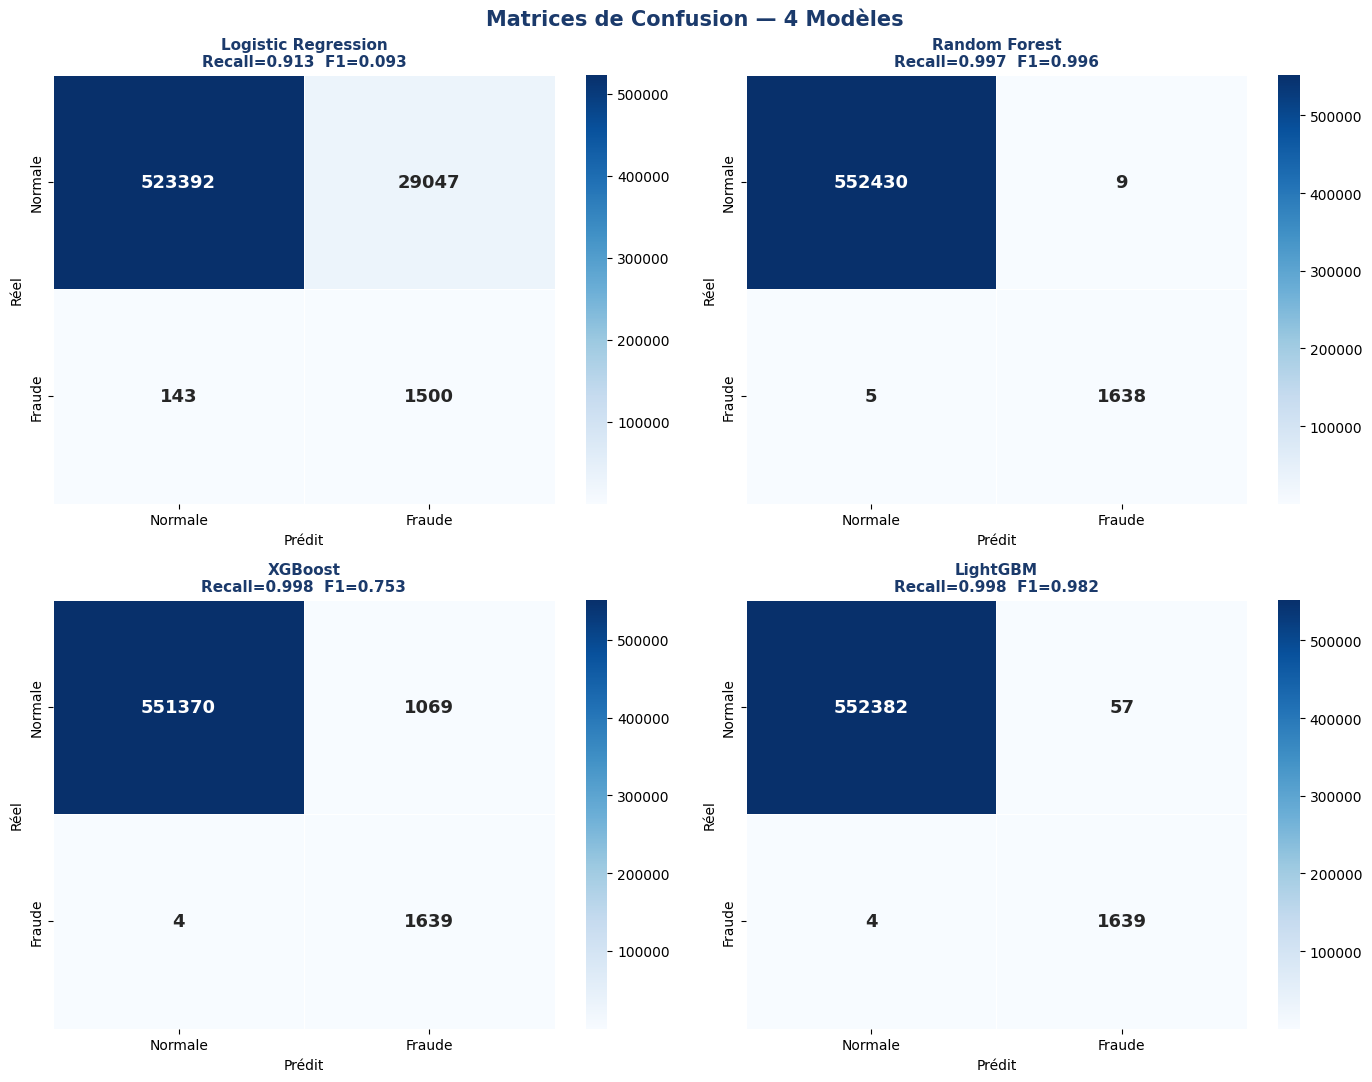

✅ Matrices de confusion sauvegardées


In [43]:
# ═══════════════════════════════════════════════════════════
# CELLULE 18 — MATRICES DE CONFUSION (4 MODÈLES)
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Matrices de Confusion — 4 Modèles",
             fontsize=15, fontweight='bold', color='#1B3A6B')

for ax, (nom, v) in zip(axes.flat, resultats.items()):
    cm = confusion_matrix(y_test, v['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Normale', 'Fraude'],
        yticklabels=['Normale', 'Fraude'],
        ax=ax, linewidths=0.5,
        annot_kws={'size': 13, 'weight': 'bold'}
    )
    ax.set_title(
        f"{nom}\nRecall={v['recall']:.3f}  F1={v['f1']:.3f}",
        fontsize=11, fontweight='bold', color='#1B3A6B'
    )
    ax.set_ylabel('Réel',   fontsize=10)
    ax.set_xlabel('Prédit', fontsize=10)

plt.tight_layout()
plt.savefig('../models/matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Matrices de confusion sauvegardées")

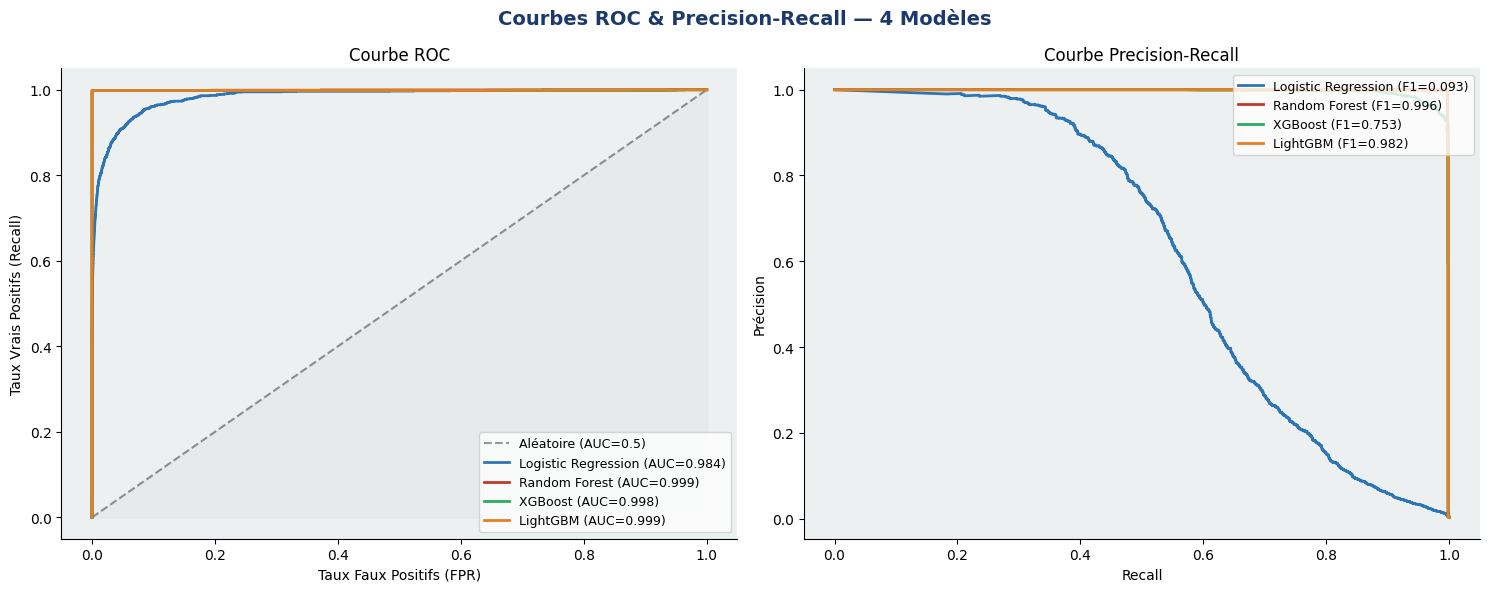

✅ Courbes ROC et PR sauvegardées


In [44]:
# ═══════════════════════════════════════════════════════════
# CELLULE 19 — COURBES ROC
# ═══════════════════════════════════════════════════════════

couleurs = [BLEU, ROUGE, VERT, ORANGE]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Courbes ROC & Precision-Recall — 4 Modèles",
             fontsize=14, fontweight='bold', color='#1B3A6B')

# ── Courbe ROC
axes[0].plot([0,1], [0,1], 'k--', alpha=0.4, label='Aléatoire (AUC=0.5)')
for (nom, v), couleur in zip(resultats.items(), couleurs):
    fpr, tpr, _ = roc_curve(y_test, v['y_proba'])
    axes[0].plot(fpr, tpr, color=couleur, lw=2,
                 label=f"{nom} (AUC={v['auc']:.3f})")
axes[0].set_title("Courbe ROC", fontsize=12)
axes[0].set_xlabel("Taux Faux Positifs (FPR)")
axes[0].set_ylabel("Taux Vrais Positifs (Recall)")
axes[0].legend(fontsize=9, loc='lower right')
axes[0].set_facecolor(GRIS)
axes[0].fill_between([0,1], [0,1], alpha=0.05, color='gray')

# ── Courbe Precision-Recall
for (nom, v), couleur in zip(resultats.items(), couleurs):
    prec, rec, _ = precision_recall_curve(y_test, v['y_proba'])
    axes[1].plot(rec, prec, color=couleur, lw=2,
                 label=f"{nom} (F1={v['f1']:.3f})")
axes[1].set_title("Courbe Precision-Recall", fontsize=12)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Précision")
axes[1].legend(fontsize=9, loc='upper right')
axes[1].set_facecolor(GRIS)

plt.tight_layout()
plt.savefig('../models/courbes_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Courbes ROC et PR sauvegardées")

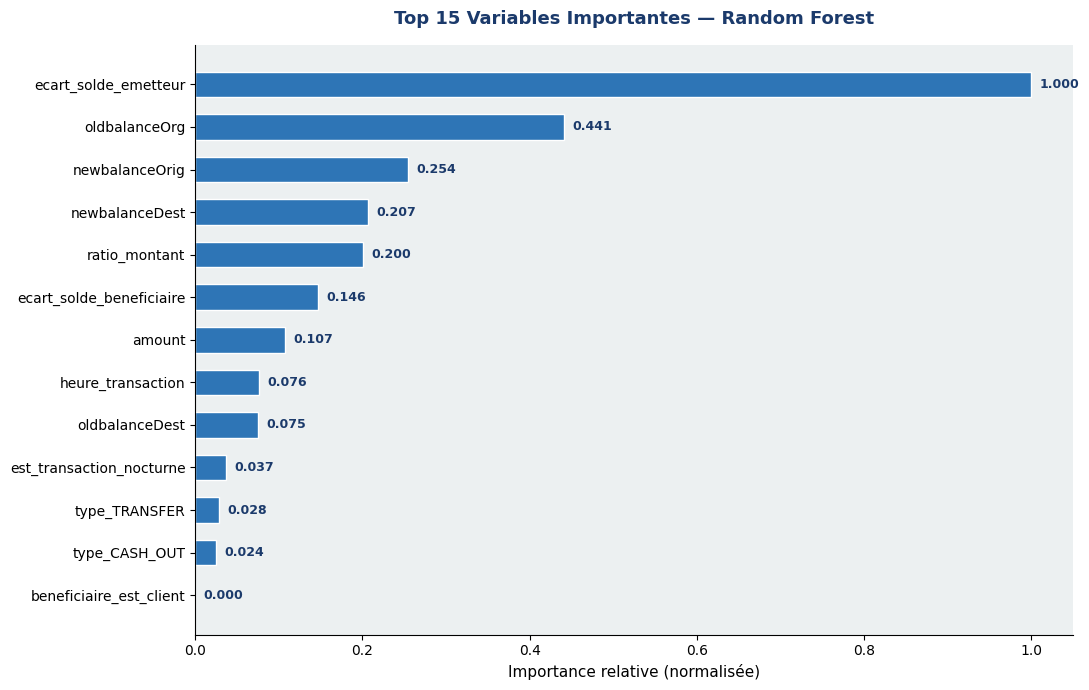

✅ Importance des variables sauvegardée
   Top 3 variables : ecart_solde_emetteur, oldbalanceOrg, newbalanceOrig


In [45]:
# ═══════════════════════════════════════════════════════════
# CELLULE 20 — IMPORTANCE DES VARIABLES (MEILLEUR MODÈLE)
# ═══════════════════════════════════════════════════════════

# Noms des colonnes après prétraitement
noms_numeriques  = FEATURES_NUMERIQUES
noms_categories  = list(
    preprocessor.named_transformers_['cat']
    .get_feature_names_out(FEATURE_CATEGORIE)
)
noms_binaires    = FEATURES_BINAIRES
tous_les_noms    = noms_numeriques + noms_categories + noms_binaires

# Récupération des importances
if hasattr(meilleur_modele, 'feature_importances_'):
    importances = meilleur_modele.feature_importances_
else:
    # Logistic Regression — utilise les coefficients absolus
    importances = np.abs(meilleur_modele.coef_[0])

# Tri et affichage
idx   = np.argsort(importances)[::-1][:15]   # top 15
noms  = [tous_les_noms[i] for i in idx]
vals  = importances[idx]
# Normalisation 0-1
vals  = vals / vals.max()

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(noms[::-1], vals[::-1],
               color=BLEU, edgecolor='white', height=0.6)
ax.set_title(
    f"Top 15 Variables Importantes — {meilleur_nom}",
    fontsize=13, fontweight='bold', color='#1B3A6B', pad=15
)
ax.set_xlabel("Importance relative (normalisée)", fontsize=11)
ax.set_facecolor(GRIS)
for bar, val in zip(bars, vals[::-1]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9,
            color='#1B3A6B', fontweight='bold')

plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Importance des variables sauvegardée")
print(f"   Top 3 variables : {noms[0]}, {noms[1]}, {noms[2]}")

In [47]:
# ═══════════════════════════════════════════════════════════
# CELLULE 21 — SAUVEGARDE DU MEILLEUR MODÈLE
# ═══════════════════════════════════════════════════════════

# Sauvegarde du modèle
joblib.dump(meilleur_modele, '../models/model.pkl')
print(f"✅ Modèle sauvegardé         → models/model.pkl")

# Sauvegarde des métriques en JSON
metriques = {
    'meilleur_modele' : meilleur_nom,
    'recall'          : round(resultats[meilleur_nom]['recall'],    4),
    'precision'       : round(resultats[meilleur_nom]['precision'], 4),
    'f1_score'        : round(resultats[meilleur_nom]['f1'],        4),
    'auc_roc'         : round(resultats[meilleur_nom]['auc'],       4),
    'comparaison'     : {
        nom: {
            'recall'   : round(v['recall'],    4),
            'precision': round(v['precision'], 4),
            'f1'       : round(v['f1'],        4),
            'auc'      : round(v['auc'],       4),
        }
        for nom, v in resultats.items()
    }
}

with open('../models/metrics.json', 'w') as f:
    json.dump(metriques, f, indent=2, ensure_ascii=False)

print(f"✅ Métriques sauvegardées    → models/metrics.json")
print(f"✅ Préprocesseur déjà sauvegardé → models/preprocessor.pkl")

print(f"""
{'='*55}
  BILAN ÉTAPE 4
{'='*55}
  Meilleur modèle : {meilleur_nom}
  Recall          : {metriques['recall']}
  Précision       : {metriques['precision']}
  F1-Score        : {metriques['f1_score']}
  AUC-ROC         : {metriques['auc_roc']}

  Fichiers sauvegardés dans models/ :
    ├─ model.pkl
    ├─ preprocessor.pkl
    └─ metrics.json

✅ Étape 4 terminée — on passe au Backend FastAPI !
{'='*55}
""")

✅ Modèle sauvegardé         → models/model.pkl
✅ Métriques sauvegardées    → models/metrics.json
✅ Préprocesseur déjà sauvegardé → models/preprocessor.pkl

  BILAN ÉTAPE 4
  Meilleur modèle : Random Forest
  Recall          : 0.997
  Précision       : 0.9945
  F1-Score        : 0.9957
  AUC-ROC         : 0.9991

  Fichiers sauvegardés dans models/ :
    ├─ model.pkl
    ├─ preprocessor.pkl
    └─ metrics.json

✅ Étape 4 terminée — on passe au Backend FastAPI !

